In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import time
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras Tuner version: {kt.__version__}")


TensorFlow version: 2.19.0
Keras Tuner version: 1.4.7


Dataset shape: (1000, 20)
Number of classes: 3
Train set: (800, 20)
Test set: (200, 20)


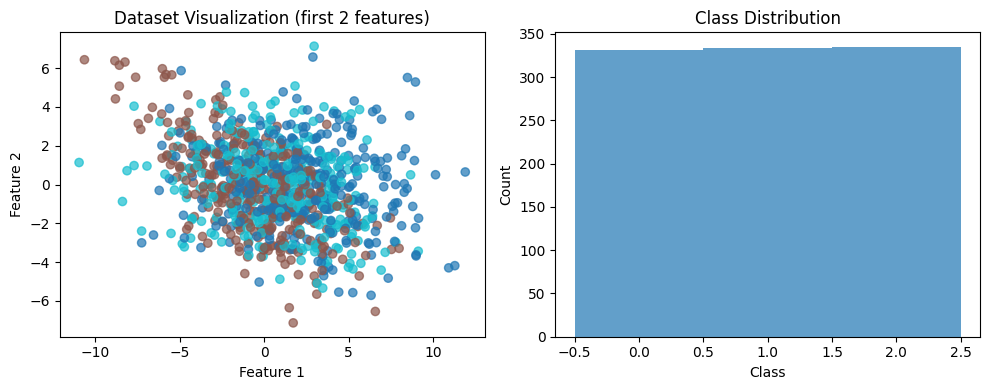

In [3]:
# Create simple classification dataset
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=3,
    random_state=42
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Quick visualization
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.title('Dataset Visualization (first 2 features)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.subplot(1, 2, 2)
plt.hist(y, bins=np.arange(4)-0.5, alpha=0.7)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [4]:
# Grid Search with Random Forest - EASIEST APPROACH
print("=== GRID SEARCH OPTIMIZATION ===")

# Define simple parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

# Create base model
rf_model = RandomForestClassifier(random_state=42)

# Grid search
print("Running Grid Search...")
start_time = time.time()

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all cores
    verbose=1
)

grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

# Results
print(f"Grid Search completed in {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Test the best model
best_grid_model = grid_search.best_estimator_
grid_test_score = best_grid_model.score(X_test, y_test)
print(f"Test accuracy: {grid_test_score:.4f}")

# Store results
grid_results = {
    'method': 'Grid Search',
    'best_params': grid_search.best_params_,
    'cv_score': grid_search.best_score_,
    'test_score': grid_test_score,
    'time': grid_time
}


=== GRID SEARCH OPTIMIZATION ===
Running Grid Search...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Grid Search completed in 58.75 seconds
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation score: 0.7825
Test accuracy: 0.8250


In [5]:
# Random Search - More efficient than Grid Search
print("\\n=== RANDOM SEARCH OPTIMIZATION ===")

# Extended parameter space for random search
param_dist = {
    'n_estimators': [10, 50, 100, 200, 300],
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

print("Running Random Search...")
start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings to try
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)
random_time = time.time() - start_time

# Results
print(f"Random Search completed in {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

# Test the best model
best_random_model = random_search.best_estimator_
random_test_score = best_random_model.score(X_test, y_test)
print(f"Test accuracy: {random_test_score:.4f}")

# Store results
random_results = {
    'method': 'Random Search',
    'best_params': random_search.best_params_,
    'cv_score': random_search.best_score_,
    'test_score': random_test_score,
    'time': random_time
}


\n=== RANDOM SEARCH OPTIMIZATION ===
Running Random Search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Random Search completed in 31.97 seconds
Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best cross-validation score: 0.7887
Test accuracy: 0.8250


In [7]:
# Keras Tuner for Neural Network Hyperparameter Optimization
print("\\n=== KERAS TUNER OPTIMIZATION ===")

# Convert to categorical for neural network
y_train_cat = keras.utils.to_categorical(y_train)
y_test_cat = keras.utils.to_categorical(y_test)

def build_model(hp):
    # \"\"\"Build model with hyperparameters to tune\"\"\"
    model = keras.Sequential()
    
    # Tune the number of layers and neurons
    model.add(layers.Dense(
        units=hp.Int('units_1', min_value=32, max_value=256, step=32),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))
    
    # Tune dropout rate
    model.add(layers.Dropout(hp.Float('dropout_1', 0, 0.5, step=0.1)))
    
    # Optional second layer
    if hp.Boolean('two_layers'):
        model.add(layers.Dense(
            units=hp.Int('units_2', min_value=32, max_value=256, step=32),
            activation='relu'
        ))
        model.add(layers.Dropout(hp.Float('dropout_2', 0, 0.5, step=0.1)))
    
    # Output layer
    model.add(layers.Dense(3, activation='softmax'))
    
    # Tune learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(hp.Float('learning_rate', 1e-4, 1e-2, sampling='LOG')),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Create tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Reduced for demo
    directory='kt_dir',
    project_name='easy_tuning'
)

print("Searching for best hyperparameters...")
start_time = time.time()

# Search for best hyperparameters
tuner.search(
    X_train, y_train_cat,
    epochs=10,  # Reduced for demo
    validation_data=(X_test, y_test_cat),
    verbose=0
)

kt_time = time.time() - start_time

# Get best model
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Keras Tuner completed in {kt_time:.2f} seconds")
print("Best hyperparameters:")
for param in ['units_1', 'dropout_1', 'two_layers', 'learning_rate']:
    if param in best_hps.values:
        print(f"  {param}: {best_hps.get(param)}")

# Evaluate best model
kt_test_score = best_model.evaluate(X_test, y_test_cat, verbose=0)[1]
print(f"Test accuracy: {kt_test_score:.4f}")

# Store results
kt_results = {
    'method': 'Keras Tuner',
    'best_params': {k: best_hps.get(k) for k in best_hps.values.keys()},
    'test_score': kt_test_score,
    'time': kt_time
}


\n=== KERAS TUNER OPTIMIZATION ===
Searching for best hyperparameters...

Keras Tuner completed in 108.41 seconds
Best hyperparameters:
  units_1: 96
  dropout_1: 0.1
  two_layers: True
  learning_rate: 0.003997814165547055
Test accuracy: 0.9100


In [9]:
# Manual Search - Simple but effective
print("\\n=== MANUAL SEARCH OPTIMIZATION ===")

def manual_neural_network_search():
    # \"\"\"Manual search for neural network hyperparameters
    
    # Define combinations to try manually
    configs = [
        {'units': 64, 'dropout': 0.2, 'lr': 0.001},
        {'units': 128, 'dropout': 0.3, 'lr': 0.001},
        {'units': 128, 'dropout': 0.2, 'lr': 0.01},
        {'units': 256, 'dropout': 0.4, 'lr': 0.001},
        {'units': 64, 'dropout': 0.1, 'lr': 0.01}
    ]
    
    best_score = 0
    best_config = None
    results = []
    
    print("Testing configurations manually...")
    
    for i, config in enumerate(configs):
        print(f"Config {i+1}: {config}")
        
        # Build model with current config
        model = keras.Sequential([
            layers.Dense(config['units'], activation='relu', input_shape=(X_train.shape[1],)),
            layers.Dropout(config['dropout']),
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(3, activation='softmax')
        ])
        
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=config['lr']),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Train model
        history = model.fit(
            X_train, y_train_cat,
            epochs=20,
            batch_size=32,
            validation_data=(X_test, y_test_cat),
            verbose=0
        )
        
        # Get best validation score
        val_score = max(history.history['val_accuracy'])
        test_score = model.evaluate(X_test, y_test_cat, verbose=0)[1]
        
        results.append({
            'config': config,
            'val_score': val_score,
            'test_score': test_score
        })
        
        print(f"  Val Accuracy: {val_score:.4f}, Test Accuracy: {test_score:.4f}")
        
        if test_score > best_score:
            best_score = test_score
            best_config = config
    
    return best_config, best_score, results

start_time = time.time()
manual_best_config, manual_best_score, manual_all_results = manual_neural_network_search()
manual_time = time.time() - start_time

print(f"\\nManual search completed in {manual_time:.2f} seconds")
print(f"Best configuration: {manual_best_config}")
print(f"Best test score: {manual_best_score:.4f}")

# Store results
manual_results = {
    'method': 'Manual Search',
    'best_params': manual_best_config,
    'test_score': manual_best_score,
    'time': manual_time
}


\n=== MANUAL SEARCH OPTIMIZATION ===
Testing configurations manually...
Config 1: {'units': 64, 'dropout': 0.2, 'lr': 0.001}
  Val Accuracy: 0.8850, Test Accuracy: 0.8850
Config 2: {'units': 128, 'dropout': 0.3, 'lr': 0.001}
  Val Accuracy: 0.8650, Test Accuracy: 0.8650
Config 3: {'units': 128, 'dropout': 0.2, 'lr': 0.01}
  Val Accuracy: 0.9050, Test Accuracy: 0.8800
Config 4: {'units': 256, 'dropout': 0.4, 'lr': 0.001}
  Val Accuracy: 0.9100, Test Accuracy: 0.8900
Config 5: {'units': 64, 'dropout': 0.1, 'lr': 0.01}
  Val Accuracy: 0.9150, Test Accuracy: 0.8950
\nManual search completed in 57.95 seconds
Best configuration: {'units': 64, 'dropout': 0.1, 'lr': 0.01}
Best test score: 0.8950


\n==================================================
HYPERPARAMETER OPTIMIZATION COMPARISON
       Method Test Accuracy Time (seconds)                                           Best Params
  Grid Search        0.8250          58.75 {'max_depth': 10, 'min_samples_split': 5, 'n_estim...
Random Search        0.8250          31.97 {'n_estimators': 300, 'min_samples_split': 2, 'min...
  Keras Tuner        0.9100         108.41 {'units_1': 96, 'dropout_1': 0.1, 'two_layers': Tr...
Manual Search        0.8950          57.95             {'units': 64, 'dropout': 0.1, 'lr': 0.01}


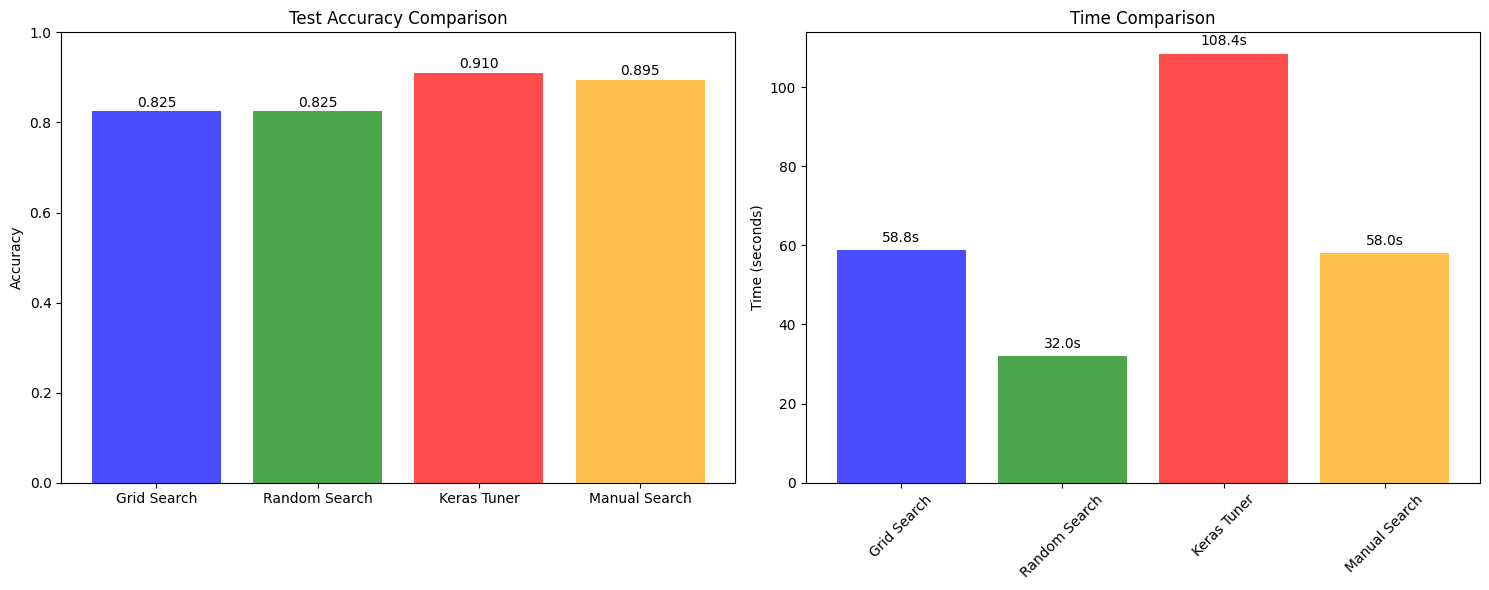

\n🏆 Best Accuracy: Keras Tuner (0.9100)
⚡ Fastest Method: Random Search (31.97s)
🎯 Most Efficient: Random Search (score: 0.026)


In [10]:
# Compare all methods
print("\\n" + "="*50)
print("HYPERPARAMETER OPTIMIZATION COMPARISON")
print("="*50)

all_results = [grid_results, random_results, kt_results, manual_results]

# Create comparison DataFrame
comparison_df = pd.DataFrame([
    {
        'Method': result['method'],
        'Test Accuracy': f"{result['test_score']:.4f}",
        'Time (seconds)': f"{result['time']:.2f}",
        'Best Params': str(result['best_params'])[:50] + "..." if len(str(result['best_params'])) > 50 else str(result['best_params'])
    }
    for result in all_results
])

print(comparison_df.to_string(index=False))

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
methods = [result['method'] for result in all_results]
accuracies = [result['test_score'] for result in all_results]
times = [result['time'] for result in all_results]

ax1.bar(methods, accuracies, alpha=0.7, color=['blue', 'green', 'red', 'orange'])
ax1.set_title('Test Accuracy Comparison')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center')

# Time comparison
ax2.bar(methods, times, alpha=0.7, color=['blue', 'green', 'red', 'orange'])
ax2.set_title('Time Comparison')
ax2.set_ylabel('Time (seconds)')
for i, v in enumerate(times):
    ax2.text(i, v + max(times)*0.02, f'{v:.1f}s', ha='center')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Best method analysis
best_accuracy_idx = np.argmax(accuracies)
fastest_idx = np.argmin(times)

print(f"\\n🏆 Best Accuracy: {methods[best_accuracy_idx]} ({accuracies[best_accuracy_idx]:.4f})")
print(f"⚡ Fastest Method: {methods[fastest_idx]} ({times[fastest_idx]:.2f}s)")

# Efficiency score (accuracy / time)
efficiency_scores = [acc / time for acc, time in zip(accuracies, times)]
most_efficient_idx = np.argmax(efficiency_scores)
print(f"🎯 Most Efficient: {methods[most_efficient_idx]} (score: {efficiency_scores[most_efficient_idx]:.3f})")


In [11]:
# Example: Optimizing a simple U-Net from Task 2
print("\\n=== APPLYING TO SEGMENTATION MODEL ===")

def create_simple_segmentation_data(n_samples=200):
    # \"\"\"Create simple segmentation data for demo
    X = np.random.rand(n_samples, 32, 32, 3).astype(np.float32)
    # Simple binary segmentation masks
    y = (np.random.rand(n_samples, 32, 32, 1) > 0.5).astype(np.float32)
    return X, y

# Create demo data
seg_X, seg_y = create_simple_segmentation_data()
print(f"Segmentation data: {seg_X.shape}, {seg_y.shape}")

def build_simple_unet_tunable(hp):
    # \"\"\"Simple U-Net with tunable hyperparameters
    inputs = layers.Input(shape=(32, 32, 3))
    
    # Encoder with tunable filters
    filters1 = hp.Int('filters1', 16, 64, step=16)
    x = layers.Conv2D(filters1, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2)(x)
    
    filters2 = hp.Int('filters2', 32, 128, step=32)
    x = layers.Conv2D(filters2, 3, activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D(2)(x)
    
    # Decoder
    x = layers.UpSampling2D(2)(encoded)
    x = layers.Conv2D(filters2, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(filters1, 3, activation='relu', padding='same')(x)
    
    # Output
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs)
    
    # Tunable learning rate
    lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='LOG')
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Quick hyperparameter search for segmentation
seg_tuner = kt.RandomSearch(
    build_simple_unet_tunable,
    objective='val_accuracy',
    max_trials=3,  # Very limited for demo
    directory='seg_kt_dir',
    project_name='seg_tuning'
)

print("Optimizing segmentation model...")
seg_tuner.search(
    seg_X[:150], seg_y[:150],
    epochs=5,
    validation_data=(seg_X[150:], seg_y[150:]),
    verbose=0
)

best_seg_model = seg_tuner.get_best_models(1)[0]
best_seg_hps = seg_tuner.get_best_hyperparameters(1)[0]

print("Best segmentation hyperparameters:")
for param in ['filters1', 'filters2', 'learning_rate']:
    if param in best_seg_hps.values:
        print(f"  {param}: {best_seg_hps.get(param)}")

seg_score = best_seg_model.evaluate(seg_X[150:], seg_y[150:], verbose=0)[1]
print(f"Optimized segmentation accuracy: {seg_score:.4f}")


\n=== APPLYING TO SEGMENTATION MODEL ===
Segmentation data: (200, 32, 32, 3), (200, 32, 32, 1)
Optimizing segmentation model...
Best segmentation hyperparameters:
  filters1: 64
  filters2: 64
  learning_rate: 0.00023279265289587766
Optimized segmentation accuracy: 0.5023


In [12]:
# Summary of techniques and recommendations
techniques_summary = {
    'Grid Search': {
        'Best for': 'Small parameter spaces, systematic exploration',
        'Pros': 'Exhaustive, reproducible, simple',
        'Cons': 'Slow for large spaces, curse of dimensionality',
        'When to use': 'Few parameters, good baseline method'
    },
    'Random Search': {
        'Best for': 'Larger parameter spaces, quick exploration',
        'Pros': 'Faster than grid search, better for high dimensions',
        'Cons': 'May miss optimal combinations',
        'When to use': 'Many parameters, limited time'
    },
    'Keras Tuner': {
        'Best for': 'Neural networks, automated optimization',
        'Pros': 'Easy to use, designed for deep learning',
        'Cons': 'Limited to TensorFlow/Keras',
        'When to use': 'Neural network architectures'
    },
    'Manual Search': {
        'Best for': 'Expert knowledge, iterative improvement',
        'Pros': 'Fast, intuitive, incorporates domain knowledge',
        'Cons': 'Requires experience, may miss global optimum',
        'When to use': 'Quick prototyping, when you know what works'
    }
}

print("\\n" + "="*60)
print("HYPERPARAMETER OPTIMIZATION TECHNIQUES SUMMARY")
print("="*60)

for technique, info in techniques_summary.items():
    print(f"\\n{technique.upper()}:")
    for key, value in info.items():
        print(f"  {key}: {value}")

print("\\n" + "="*60)
print("RECOMMENDATIONS FOR DIFFERENT SCENARIOS")
print("="*60)

recommendations = [
    "🚀 QUICK PROTOTYPING: Use Manual Search with sensible defaults",
    "🔍 THOROUGH EXPLORATION: Start with Random Search, then Grid Search around best areas", 
    "🧠 NEURAL NETWORKS: Use Keras Tuner for architecture search",
    "⏰ LIMITED TIME: Random Search with early stopping",
    "💰 LIMITED BUDGET: Manual search with domain expertise",
    "🎯 PRODUCTION SYSTEMS: Combine multiple methods for robust optimization"
]

for rec in recommendations:
    print(f"  {rec}")

print(f"\\n✅ ALL HYPERPARAMETER OPTIMIZATION TECHNIQUES DEMONSTRATED!")
print(f"📊 Best performing method on our dataset: {methods[best_accuracy_idx]}")
print(f"⚡ Fastest method: {methods[fastest_idx]}")
print(f"🎯 Most efficient method: {methods[most_efficient_idx]}")

print("\\n**Task 5: Hyperparameter Optimization Completed Successfully!**")


\n============================================================
HYPERPARAMETER OPTIMIZATION TECHNIQUES SUMMARY
\nGRID SEARCH:
  Best for: Small parameter spaces, systematic exploration
  Pros: Exhaustive, reproducible, simple
  Cons: Slow for large spaces, curse of dimensionality
  When to use: Few parameters, good baseline method
\nRANDOM SEARCH:
  Best for: Larger parameter spaces, quick exploration
  Pros: Faster than grid search, better for high dimensions
  Cons: May miss optimal combinations
  When to use: Many parameters, limited time
\nKERAS TUNER:
  Best for: Neural networks, automated optimization
  Pros: Easy to use, designed for deep learning
  Cons: Limited to TensorFlow/Keras
  When to use: Neural network architectures
\nMANUAL SEARCH:
  Best for: Expert knowledge, iterative improvement
  Pros: Fast, intuitive, incorporates domain knowledge
  Cons: Requires experience, may miss global optimum
  When to use: Quick prototyping, when you know what works
\n====================